In [1]:
# importer les packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itables import show
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
import folium
import requests
from IPython.display import display, HTML
import branca
import copy
import plotly.express as px
import plotly.graph_objects as go
import json
import ipywidgets as widgets
from IPython.display import display, clear_output
from plotly.subplots import make_subplots
pd.set_option('display.max_rows', None)

---
# Introduction

L’insécurité et la violence en France suscitent depuis de nombreuses années une attention
croissante, au point d’occuper une place importante dans le débat public. 

Certains s’inquiètent d’une hausse récente des actes violents, allant parfois jusqu’à en généraliser les
causes. 

Pourtant, la violence ne peut être réduite à une explication unique. 

De nombreux facteurs, d’ordres économique, social, psychologique ou encore territorial, peuvent conduire
un individu à commettre un acte violent, qu’il s’agisse d’un simple vol ou d’un homicide.

Le terme même de violence est vaste, englobant toute forme d’abus ou d’agression par la
force. 

Les faits de violence sont donc multiples, hétérogènes, et souvent issus de logiques très
différentes.

Entre récupération politique et manque d’approfondissement scientifique, les déterminants de
la violence récente en France restent encore largement méconnus. 

Dans cette étude, nous proposons d’adopter une approche économétrique afin d’identifier les principaux facteurs
susceptibles d’expliquer les faits de violence.

Plus précisément, notre analyse portera sur les 101 départements français, dans le but
d’examiner l’influence de variables sociodémographiques, économiques et territoriales sur
plusieurs types de violences.

L’objectif est d’aboutir à un ou plusieurs modèles économétriques, permettant une interprétation fine des déterminants de
la violence à l’échelle départementale.

Enfin, à partir des résultats obtenus, nous proposerons une réflexion sur les facteurs les plus déterminants de la violence en France. 

---

## Documentation du Projet : Synthèse des Variables et Sources

---

### 1. Variables Explicatives (X) — Causes & Contexte

| Nom Technique | Unité | Description | Source | Lien URL |
| :--- | :--- | :--- | :--- | :--- |
| `densite_population` | **hab/km²** | Densité de population | INSEE | [Lien](https://www.insee.fr/fr/statistiques/5544529?sommaire=5435421#tableau-figure2) |
| `population_insee` | **Nombre** | Population totale du département | INSEE | [Lien](https://www.insee.fr/fr/statistiques/5544529?sommaire=5435421#tableau-figure2) |
| `taux_chomage` | **%** | Part des actifs au chômage | INSEE | [Lien](https://www.insee.fr/fr/statistiques/5391982?sommaire=5392045) |
| `taux_pauvrete_60` | **%** | Part sous le seuil de pauvreté | INSEE | [Lien](https://www.insee.fr/fr/statistiques/6692414?sommaire=6692394#tableau-figure1_radio1) |
| `niveau_vie_median` | **Euros** | Revenu annuel médian | INSEE | [Lien](https://www.insee.fr/fr/statistiques/6692414?sommaire=6692394#tableau-figure1_radio1) |
| `part_jeunes_difficulte_lecture` | **%** | Difficultés de lecture (JDC) | Ministère Éducation | [Lien](https://www.education.gouv.fr/journee-defense-et-citoyennete-2020-pres-d-un-jeune-francais-sur-dix-en-difficulte-de-lecture-323603) |
| `part_non_diplomes` | **%** | Jeunes (15-24 ans) non diplômés | INSEE | [Lien](https://www.insee.fr/fr/statistiques/5020064?sommaire=5040030) |
| `part_moins_25_ans` | **%** | Part de la population < 25 ans | INSEE | [Lien](https://www.insee.fr/fr/statistiques/5544529?sommaire=5435421#tableau-figure2) |
| `part_immigres` | **%** | Part des immigrés | INSEE | [Lien](https://www.insee.fr/fr/statistiques/6793282?sommaire=6793391) |
| `part_descendants_immigres` | **%** | Part des descendants d'immigrés | INSEE | [Lien](https://www.insee.fr/fr/statistiques/6793282?sommaire=6793391) |
| `trafic_stupefiants` | **Taux ‰** | Trafic de stupéfiants | SSMSI | [Lien](https://www.data.gouv.fr/datasets/bases-statistiques-communale-departementale-et-regionale-de-la-delinquance-enregistree-par-la-police-et-la-gendarmerie-nationales/) |
| `usage_stupefiants_total` | **Taux ‰** | Usage de stupéfiants | SSMSI | [Lien](https://www.data.gouv.fr/datasets/bases-statistiques-communale-departementale-et-regionale-de-la-delinquance-enregistree-par-la-police-et-la-gendarmerie-nationales/) |

---

### 2. Variables Dépendantes (Y) — Crimes & Délits

| Nom Technique | Unité | Libellé de l'Indicateur | Source & Lien |
| :--- | :--- | :--- | :--- |
| `homicides` | **Taux ‰** | Homicides | [Lien Unique SSMSI](https://www.data.gouv.fr/datasets/bases-statistiques-communale-departementale-et-regionale-de-la-delinquance-enregistree-par-la-police-et-la-gendarmerie-nationales/) |
| `tentatives_homicide` | **Taux ‰** | Tentatives d'homicide | [Lien Unique SSMSI](https://www.data.gouv.fr/datasets/bases-statistiques-communale-departementale-et-regionale-de-la-delinquance-enregistree-par-la-police-et-la-gendarmerie-nationales/) |
| `violences_physiques_hors_famille` | **Taux ‰** | Violences physiques hors cadre familial | [Lien Unique SSMSI](https://www.data.gouv.fr/datasets/bases-statistiques-communale-departementale-et-regionale-de-la-delinquance-enregistree-par-la-police-et-la-gendarmerie-nationales/) |
| `violences_physiques_intrafamiliales` | **Taux ‰** | Violences physiques intrafamiliales | [Lien Unique SSMSI](https://www.data.gouv.fr/datasets/bases-statistiques-communale-departementale-et-regionale-de-la-delinquance-enregistree-par-la-police-et-la-gendarmerie-nationales/) |
| `violences_sexuelles` | **Taux ‰** | Violences sexuelles | [Lien Unique SSMSI](https://www.data.gouv.fr/datasets/bases-statistiques-communale-departementale-et-regionale-de-la-delinquance-enregistree-par-la-police-et-la-gendarmerie-nationales/) |
| `vols_avec_armes` | **Taux ‰** | Vols commis avec une arme | [Lien Unique SSMSI](https://www.data.gouv.fr/datasets/bases-statistiques-communale-departementale-et-regionale-de-la-delinquance-enregistree-par-la-police-et-la-gendarmerie-nationales/) |
| `vols_violents_sans_arme` | **Taux ‰** | Vols violents sans arme | [Lien Unique SSMSI](https://www.data.gouv.fr/datasets/bases-statistiques-communale-departementale-et-regionale-de-la-delinquance-enregistree-par-la-police-et-la-gendarmerie-nationales/) |
| `vols_sans_violence` | **Taux ‰** | Vols sans violence contre des personnes | [Lien Unique SSMSI](https://www.data.gouv.fr/datasets/bases-statistiques-communale-departementale-et-regionale-de-la-delinquance-enregistree-par-la-police-et-la-gendarmerie-nationales/) |
| `cambriolages_logement` | **Taux ‰** | Cambriolages de logement | [Lien Unique SSMSI](https://www.data.gouv.fr/datasets/bases-statistiques-communale-departementale-et-regionale-de-la-delinquance-enregistree-par-la-police-et-la-gendarmerie-nationales/) |
| `vols_vehicule` | **Taux ‰** | Vols de véhicule | [Lien Unique SSMSI](https://www.data.gouv.fr/datasets/bases-statistiques-communale-departementale-et-regionale-de-la-delinquance-enregistree-par-la-police-et-la-gendarmerie-nationales/) |
| `vols_dans_vehicules` | **Taux ‰** | Vols dans les véhicules | [Lien Unique SSMSI](https://www.data.gouv.fr/datasets/bases-statistiques-communale-departementale-et-regionale-de-la-delinquance-enregistree-par-la-police-et-la-gendarmerie-nationales/) |
| `vols_accessoires_vehicules` | **Taux ‰** | Vols d'accessoires sur véhicules | [Lien Unique SSMSI](https://www.data.gouv.fr/datasets/bases-statistiques-communale-departementale-et-regionale-de-la-delinquance-enregistree-par-la-police-et-la-gendarmerie-nationales/) |
| `destructions_degradations` | **Taux ‰** | Destructions et dégradations volontaires | [Lien Unique SSMSI](https://www.data.gouv.fr/datasets/bases-statistiques-communale-departementale-et-regionale-de-la-delinquance-enregistree-par-la-police-et-la-gendarmerie-nationales/) |
| `escroqueries_fraudes` | **Taux ‰** | Escroqueries et fraudes | [Lien Unique SSMSI](https://www.data.gouv.fr/datasets/bases-statistiques-communale-departementale-et-regionale-de-la-delinquance-enregistree-par-la-police-et-la-gendarmerie-nationales/) |

---

**Référentiel Géographique :** [Départements de France (Etalab)](https://www.data.gouv.fr/datasets/departements-de-france/)

# 1. Fetch

In [2]:
# Base de données des noms et codes départements pour faciliter le traitements des données
departements = pd.read_csv('DATA_PROJET/departements-france.csv')

# Correspond à la base de données sur la délinquance: un grand nombre de variables liées à la violence qu'il faudra traiter
# ( les coups et blessures volontaires, et les vols avec armes sont dedans ) : nos variables expliquées.
base_stat_deliquance = pd.read_csv("DATA_PROJET/donnee-dep-data.gouv-2024-geographie2025-produit-le2025-06-04.csv", sep = ";")

# Correspond au taux de chômage par département (2020)
taux_chomage = pd.read_excel("DATA_PROJET/ECRT2021-F12.xlsx", sheet_name='Figure 2b' )

# correspond aux jeunes (16-24 ans) peu/pas diplomés qui ne font pas d'études (2017)
non_diplomes = pd.read_excel("DATA_PROJET/FET2021-6 (1).xlsx", sheet_name='Figure 2a' )

# correspond à la densité de population (2018)
densite_population = pd.read_excel("DATA_PROJET/FPORSOC21-F41.xlsx", sheet_name='figure 3' )

# correspond à la part de moins de 25 ans (2018)
moins_25_ans = pd.read_excel("DATA_PROJET/FPORSOC21-F41.xlsx", sheet_name='figure 4' )

# correspond à la part d'immigrés dans la population (2020 - 2021)
immigres  = pd.read_excel("DATA_PROJET/IMMFRA23-F30.xlsx", sheet_name='Figure 1' )

# correspond à la part des descendants d'immigrés dans la population (2020 - 2021)
descendants_immigres = pd.read_excel("DATA_PROJET/IMMFRA23-F30.xlsx", sheet_name='Figure 2' )

# correspond à la part des jeunes en difficulté de lecture (2020)
difficulte_lecture = pd.read_excel("DATA_PROJET/ni-21-27-donn-es-89912 (2).xlsx", sheet_name='Fig 4' )

# Les données sur le niveau de vie et la pauvreté ne sont pas accessibles en téléchargement, on utilise pd.read-html
url = 'https://www.insee.fr/fr/statistiques/6692414?sommaire=6692394#tableau-figure1_radio1'
df = pd.read_html(url, decimal=',', thousands=' ')
# niveau de vie médian par département en 2020
niveau_vie_median = df[0]

# Taux de pauvreté par département en 2020
taux_pauvrete = df[2]


Cette étape assure l'**importation et la centralisation des données brutes** (fichiers CSV, Excel et extraction HTML) provenant de l'INSEE et du SSMSI afin de constituer le socle multidimensionnel nécessaire à l'analyse.

# 2. Clean

### Nettoyer les données et standardiser les noms de colonnes

In [3]:
# --- 1. DONNÉES AVEC NOMS DE DÉPARTEMENTS SEULEMENT ---

# Difficulté Lecture
difficulte_lecture = difficulte_lecture.iloc[1:, [2, 3]] 
difficulte_lecture = difficulte_lecture.drop(difficulte_lecture.index[102:107]) 
difficulte_lecture = difficulte_lecture.drop(1) 
difficulte_lecture.columns = ['nom_departement', 'part_jeunes_difficulte_lecture'] # Standardisé

# Taux Chômage
taux_chomage = taux_chomage.drop(taux_chomage.index[0:1])
taux_chomage = taux_chomage.drop(taux_chomage.index[100:107])
taux_chomage.columns = ['nom_departement', 'taux_chomage'] # Standardisé

# Pauvreté 
taux_pauvrete.columns = ['nom_departement', 'taux_pauvrete_60'] # Standardisé (retrait du %)

# Niveau de vie
niveau_vie_median.columns = ['nom_departement', 'niveau_vie_median'] # Standardisé
# Enlever les espaces des milliers + convertir en numerique
niveau_vie_median['niveau_vie_median'] = niveau_vie_median['niveau_vie_median'].astype(str).str.replace(r'\s+', '', regex=True)
niveau_vie_median['niveau_vie_median'] = pd.to_numeric(niveau_vie_median['niveau_vie_median'])


# --- 2. DONNÉES AVEC CODES DÉPARTEMENTS ---

# Descendants Immigrés
descendants_immigres = descendants_immigres.drop(descendants_immigres.index[0:2])
descendants_immigres = descendants_immigres.drop(descendants_immigres.index[100:107])
descendants_immigres = descendants_immigres.iloc[:, [0, 1, 2]] 
descendants_immigres.columns = ['code_departement', 'nom_departement', 'part_descendants_immigres'] # Standardisé
# CORRECTION : Gestion des valeurs 'ns' errors='coerce' force la conversion : si c'est un chiffre, ça marche. Si c'est 'ns', ça devient NaN.
descendants_immigres['part_descendants_immigres'] = pd.to_numeric(descendants_immigres['part_descendants_immigres'], errors='coerce')

# Immigrés
immigres = immigres.drop(immigres.index[0:2])
immigres = immigres.drop(immigres.index[100:107])
immigres = immigres.iloc[:, [0, 1, 2]]
immigres.columns = ['code_departement', 'nom_departement', 'part_immigres'] # Standardisé

# Moins de 25 ans
moins_25_ans = moins_25_ans.drop(moins_25_ans.index[0:2])
moins_25_ans = moins_25_ans.drop(moins_25_ans.index[101:107])
moins_25_ans = moins_25_ans.iloc[:, [0, 1, 2]]
moins_25_ans.columns = ['code_departement', 'nom_departement', 'part_moins_25_ans'] # Standardisé

# Densité
densite_population = densite_population.drop(densite_population.index[0:2])
densite_population = densite_population.drop(densite_population.index[101:107])
densite_population = densite_population.iloc[:, [0, 1, 2]]
densite_population.columns = ['code_departement', 'nom_departement', 'densite_population'] # Standardisé

# Non Diplomés
non_diplomes = non_diplomes.drop(non_diplomes.index[0:1])
non_diplomes = non_diplomes.drop(non_diplomes.index[101:107])
non_diplomes = non_diplomes.iloc[:, [0, 1, 2]] 
non_diplomes.columns = ['code_departement', 'nom_departement', 'part_non_diplomes'] # Standardisé
# Correction format Code Département (exemple : '1' -> '01')
non_diplomes['code_departement'] = non_diplomes['code_departement'].astype(str).str.zfill(2)

Cette étape réalise le **nettoyage et la normalisation** des différents jeux de données : suppression des lignes superflues, standardisation des noms de colonnes et **conversion des formats** (numérisation des types et formatage des codes départementaux) pour garantir la parfaite interopérabilité des variables lors des fusions.

### Nettoyer le dataframe sur la délinquance

In [4]:
# 1. Filtrer pour ne garder que l'année 2020
df_crime = base_stat_deliquance[base_stat_deliquance['annee'] == 2020].copy()

# 2. Nettoyage : Remplacer les virgules par des points pour convertir en nombres flottants
# (Indispensable car '0,0078' est souvent lu comme du texte dans les fichiers français)
if df_crime['taux_pour_mille'].dtype == object:
    df_crime['taux_pour_mille'] = df_crime['taux_pour_mille'].str.replace(',', '.').astype(float)

# 3. Pivot : Créer une colonne par indicateur
# On utilise maintenant values='taux_pour_mille'
df_crime_pivot = df_crime.pivot(index='Code_departement', columns='indicateur', values='taux_pour_mille')

# 4. Ré-intégrer la population (insee_pop)
pop_data = df_crime[['Code_departement', 'insee_pop']].drop_duplicates().set_index('Code_departement')
df_crime_final = df_crime_pivot.join(pop_data)

# Renommer l'index
df_crime_final.index.name = 'code_departement'

### Standardiser les noms de colonnes du dataframe sur la délinquance

In [5]:
# Dictionnaire de correspondance : Ancien nom -> Nouveau nom standardisé
map_noms_crimes = {
    'Cambriolages de logement': 'cambriolages_logement',
    'Destructions et dégradations volontaires': 'destructions_degradations',
    'Escroqueries et fraudes aux moyens de paiement': 'escroqueries_fraudes',
    'Homicides': 'homicides',
    "Tentatives d'homicide": 'tentatives_homicide',
    'Trafic de stupéfiants': 'trafic_stupefiants',
    'Usage de stupéfiants': 'usage_stupefiants_total',
    'Usage de stupéfiants (AFD)': 'usage_stupefiants_afd',
    'Usage de stupéfiants (hors AFD)': 'usage_stupefiants_hors_afd',
    'Violences physiques hors cadre familial': 'violences_physiques_hors_famille',
    'Violences physiques intrafamiliales': 'violences_physiques_intrafamiliales',
    'Violences sexuelles': 'violences_sexuelles',
    'Vols avec armes': 'vols_avec_armes',
    "Vols d'accessoires sur véhicules": 'vols_accessoires_vehicules',
    'Vols dans les véhicules': 'vols_dans_vehicules',
    'Vols de véhicule': 'vols_vehicule',
    'Vols sans violence contre des personnes': 'vols_sans_violence',
    'Vols violents sans arme': 'vols_violents_sans_arme',
    'insee_pop': 'population_insee'
}

# On applique le renommage
df_crime_final.rename(columns=map_noms_crimes, inplace=True)

# 3. Structure 

### Merge les dataframes

In [6]:
# 1. On part de la base propre
df_final = departements[['code_departement', 'nom_departement', 'code_region', 'nom_region']].copy()

# 2. Fusions basées sur le NOM (fichiers sans codes)
# Les dataframes sources ont déjà été renommés proprement à l'étape précédente, le merge suit automatiquement.
df_final = df_final.merge(taux_chomage, on='nom_departement', how='left')
df_final = df_final.merge(taux_pauvrete, on='nom_departement', how='left')
df_final = df_final.merge(niveau_vie_median, on='nom_departement', how='left')
df_final = df_final.merge(difficulte_lecture, on='nom_departement', how='left')

# 3. Fusions basées sur le CODE
# ATTENTION : Ici, j'ai mis à jour les noms de colonnes (minuscules) pour qu'ils matchent votre standardisation
df_final = df_final.merge(descendants_immigres[['code_departement', 'part_descendants_immigres']], on='code_departement', how='left')
df_final = df_final.merge(immigres[['code_departement', 'part_immigres']], on='code_departement', how='left')
df_final = df_final.merge(moins_25_ans[['code_departement', 'part_moins_25_ans']], on='code_departement', how='left')
df_final = df_final.merge(densite_population[['code_departement', 'densite_population']], on='code_departement', how='left')
df_final = df_final.merge(non_diplomes[['code_departement', 'part_non_diplomes']], on='code_departement', how='left')

# 4. Ajout des crimes 
if 'df_crime_final' in locals():
    df_final = df_final.merge(df_crime_final, left_on='code_departement', right_index=True, how='left')

# Retirer les dpt d'outre mer
df_final = df_final[~df_final['code_departement'].str.startswith('97')]

# CONVERSION DES COLONNES "OBJECT" EN "FLOAT"
# Liste des colonnes censées être numériques mais détectées comme 'object'
cols_to_fix = [
    'taux_chomage',
    'part_jeunes_difficulte_lecture',
    'part_immigres',
    'part_moins_25_ans',
    'densite_population',
    'part_non_diplomes'
]

for col in cols_to_fix:
    # On vérifie si la colonne est bien de type object avant de traiter
    if df_final[col].dtype == 'object':
        # 1. On force la conversion en string
        # 2. On remplace la virgule par un point (format US/Python)
        # 3. On convertit en float
        df_final[col] = df_final[col].astype(str).str.replace(',', '.').astype(float)

# Suppression des colonnes inutiles
# inplace=True applique la modification directement sur df_final sans avoir à le réassigner
df_final.drop(columns=['usage_stupefiants_afd', 'usage_stupefiants_hors_afd'], inplace=True)


Cette étape opère la **fusion complète des sources thématiques** (social, économie, délinquance) via des jointures sur clés géographiques, complétée par un **raffinage technique final** incluant le filtrage de la France métropolitaine, la correction des formats numériques et le nettoyage des variables résiduelles.

In [7]:
# Placer les variables explicatives à gauche du dataframe et les dpéendantes à droite.
cols_x = [
    'densite_population', 'population_insee', 'taux_chomage', 'taux_pauvrete_60',
    'niveau_vie_median', 'part_jeunes_difficulte_lecture', 'part_non_diplomes',
    'part_moins_25_ans', 'part_immigres', 'part_descendants_immigres',
    'trafic_stupefiants', 'usage_stupefiants_total'
]

cols_y = [
    'homicides', 'tentatives_homicide', 'violences_physiques_hors_famille',
    'violences_physiques_intrafamiliales', 'violences_sexuelles', 'vols_avec_armes',
    'vols_violents_sans_arme', 'vols_sans_violence', 'cambriolages_logement',
    'vols_vehicule', 'vols_dans_vehicules', 'vols_accessoires_vehicules',
    'destructions_degradations', 'escroqueries_fraudes'
]

# 2. Identifier les colonnes "autres" (Identifiants, Régions, etc.)
# Ce sont toutes les colonnes du DF qui ne sont PAS dans X ni dans Y
cols_meta = [c for c in df_final.columns if c not in cols_x and c not in cols_y]

# 3. Vérifier quelles colonnes X et Y sont réellement présentes (sécurité)
final_x = [c for c in cols_x if c in df_final.columns]
final_y = [c for c in cols_y if c in df_final.columns]

# 4. Réorganiser : Métadonnées d'abord, puis X, puis Y
df_final = df_final[cols_meta + final_x + final_y]

In [8]:
# On vérifie que les données sont bien formatées
df_final.dtypes

code_departement                        object
nom_departement                         object
code_region                              int64
nom_region                              object
densite_population                     float64
population_insee                         int64
taux_chomage                           float64
taux_pauvrete_60                       float64
niveau_vie_median                      float64
part_jeunes_difficulte_lecture         float64
part_non_diplomes                      float64
part_moins_25_ans                      float64
part_immigres                          float64
part_descendants_immigres              float64
trafic_stupefiants                     float64
usage_stupefiants_total                float64
homicides                              float64
tentatives_homicide                    float64
violences_physiques_hors_famille       float64
violences_physiques_intrafamiliales    float64
violences_sexuelles                    float64
vols_avec_arm

In [9]:
# On sauvegarde sans l'index (pour ne pas avoir une colonne 'Unnamed: 0' à la réouverture)
# cela nous permet d'éviter d'avoir à exécuter tous les chunks lors de la réouverture du notebook
df_final.to_csv("DATA_PROJET/base_departements_complete_2020.csv", index=False)

show(df_final)

Loading ITables v2.6.1 from the internet... (need help?)


Le DataFrame `df_final` constitue désormais la base de données consolidée et structurée pour l'ensemble de l'étude. Elle regroupe **30 colonnes thématiques** (identifiants géographiques, indicateurs socio-économiques et taux de délinquance) dont les types ont été optimisés (`float64` pour les analyses statistiques et `object` pour les référentiels) afin de permettre les calculs de corrélation et les modélisations à venir.

# 4. Model

In [10]:
df_final = pd.read_csv('DATA_PROJET/base_departements_complete_2020.csv')

## 4.1 Matrice de corrélation

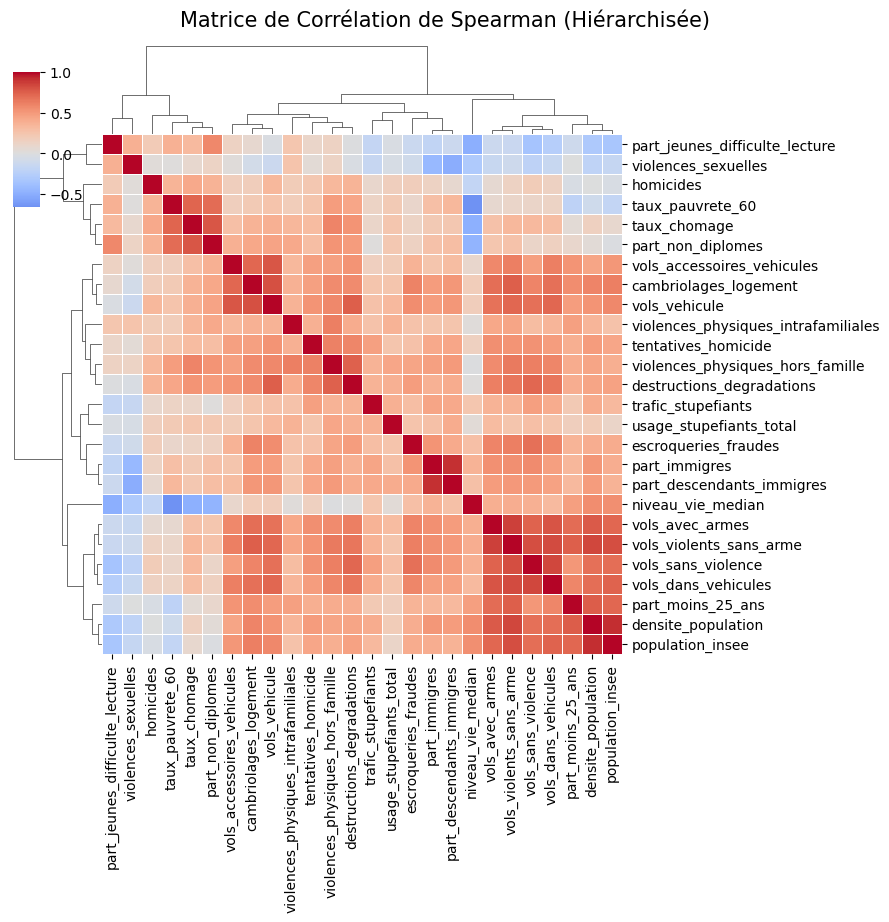

In [11]:
# 1. Sélection des données (variables quantitatives uniquement)
df_analyse = df_final.iloc[:, 4:]

# 2. Calcul de la matrice de corrélation de SPEARMAN
# L'argument method='spearman' change tout le calcul
corr_spearman = df_analyse.corr(method='spearman')

# 3. Création du Clustermap (Heatmap + Arbres de regroupement)
# On utilise une variable pour stocker le graphique afin de pouvoir le modifier
g = sns.clustermap(
    corr_spearman,
    method='ward',       # Méthode de classification (Ward minimise la variance)
    cmap='coolwarm',     # Couleurs : Rouge (+) / Bleu (-)
    center=0,            # Le blanc est à 0
    linewidths=0.5,      # Fines lignes blanches pour séparer les cases
    figsize=(9,9),    # Grande taille pour lisibilité
    dendrogram_ratio=0.15, # Taille de l'arbre (15% de l'image)
    cbar_pos=(0.02, 0.8, 0.03, 0.15) # Position de la légende (à gauche)
)

# 4. Titre et ajustements
g.fig.suptitle("Matrice de Corrélation de Spearman (Hiérarchisée)", fontsize=15, y=1.02)
plt.show()

### Analyse de la Matrice de Corrélation et Identification des Clusters

L'examen de la matrice de corrélation révèle une structuration des données en trois pôles distincts, visibles sur le dendogramme. Ces regroupements thématiques permettent d'identifier les variables qui évoluent conjointement et de définir des axes d'analyse spécifiques.

#### 1. Cluster "Crimes et précarité "
Ce pôle met en évidence un lien statistique entre la précarité structurelle et les formes les plus graves de violence.
* **Indicateurs Socio-économiques :** `taux_pauvrete_60`, `taux_chomage`, `part_non_diplomes`, `part_jeunes_difficulte_lecture`.
* **Variables de Délinquance :** `homicides`, `violences_sexuelles`.

#### 2. Cluster "Tensions urbaines et délinquance de rue"
Ce bloc regroupe les infractions liées à l'usage de l'espace public et aux dynamiques de quartiers sensibles.
* **Indicateurs Socio-démographiques :** `part_descendants_immigres`, `part_immigres`, `trafic_stupefiants`, `usage_stupefiants_total`
* **Variables de Délinquance :**  `destructions_degradations`, `violences_physiques` (intra et hors famille), `tentatives_homicide`, `escroqueries_fraudes`.

#### 3. Cluster "Vols et urbanisation"
Ce pôle est dominé par les crimes liés au gain matériel, très fortement corrélés au volume de cibles potentielles.
* **Indicateurs de Densité :** `densite_population`, `population_insee`, `part_moins_25_ans`, `niveau_vie_median`.
* **Variables de Délinquance :** `vols_sans_violence`, `cambriolages_logement`, `vols_vehicule`, `vols_dans_vehicules`, `vols_accessoires_vehicules`, `vols_violents` (avec et sans armes).

### Stratégie de Modélisation
Afin d'éviter les problèmes de multicolinéarité (variables trop corrélées entre elles au sein d'un même modèle) et pour gagner en précision, nous allons traiter chaque cluster indépendamment. Cette approche permet de tester des hypothèses spécifiques à chaque type de phénomène criminel plutôt que de chercher une explication globale unique.

## 4.2 Cluster `Crimes et précarité`

Plutôt que de créer un indice composite par sommation de : `violences_sexuelles` et `homicides`— ce qui introduirait un biais d'échelle où les variables à forte variance ( violence sexuelles) écraseraient les plus rares ( homicides) — nous privilégions une approche par régression individuelle. Cette méthode permet d'isoler les déterminants spécifiques à chaque type d'infraction sans masquer les signaux faibles par un effet d'agrégation artificiel.

Comparaison des échelles (Taux pour 1000 hab) :


,homicides,violences_sexuelles
mean,0.010768,1.148225
std,0.007351,0.192242
min,0.000000,0.783514
max,0.048353,1.823816


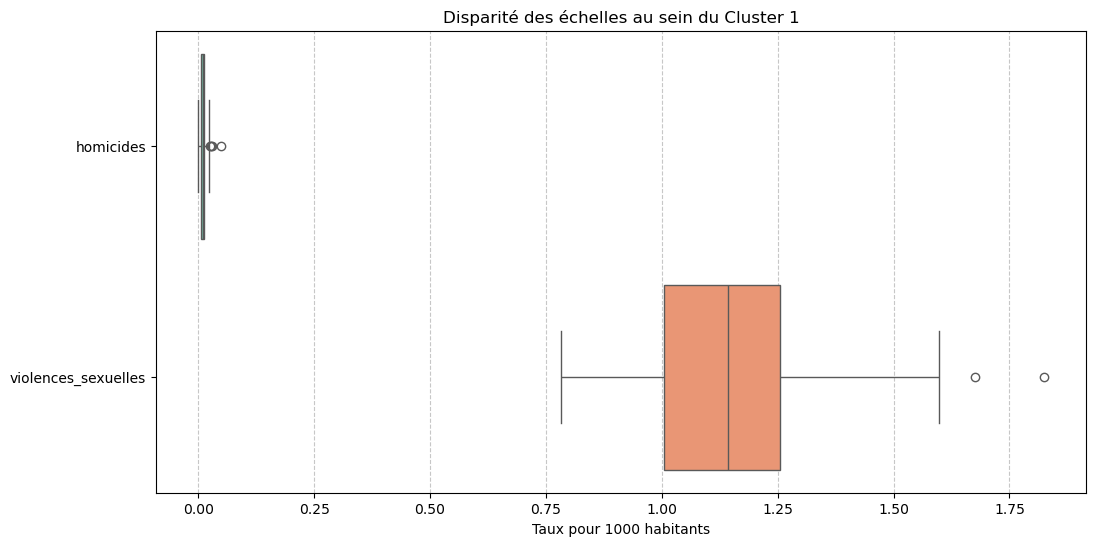

In [12]:
# Sélection des variables du Cluster 1 (Crimes graves / rares)
cols_cluster_1 = [
    'homicides',  
    'violences_sexuelles'
]

# 1. Analyse descriptive pour comparer les échelles
stats_compare = df_final[cols_cluster_1].describe().loc[['mean', 'std', 'min', 'max']]
print("Comparaison des échelles (Taux pour 1000 hab) :")
display(stats_compare)

# 2. Visualisation de la disparité (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_final[cols_cluster_1], orient='h', palette='Set2')
plt.title("Disparité des échelles au sein du Cluster 1")
plt.xlabel("Taux pour 1000 habitants")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



Les violences sexuelles sont plus de 100 fois plus courantes que les homicides, ce qui rend effectivement impossible la création d'un indice.

### 4.2.1 Modelisation des homicides

<Figure size 2500x400 with 0 Axes>

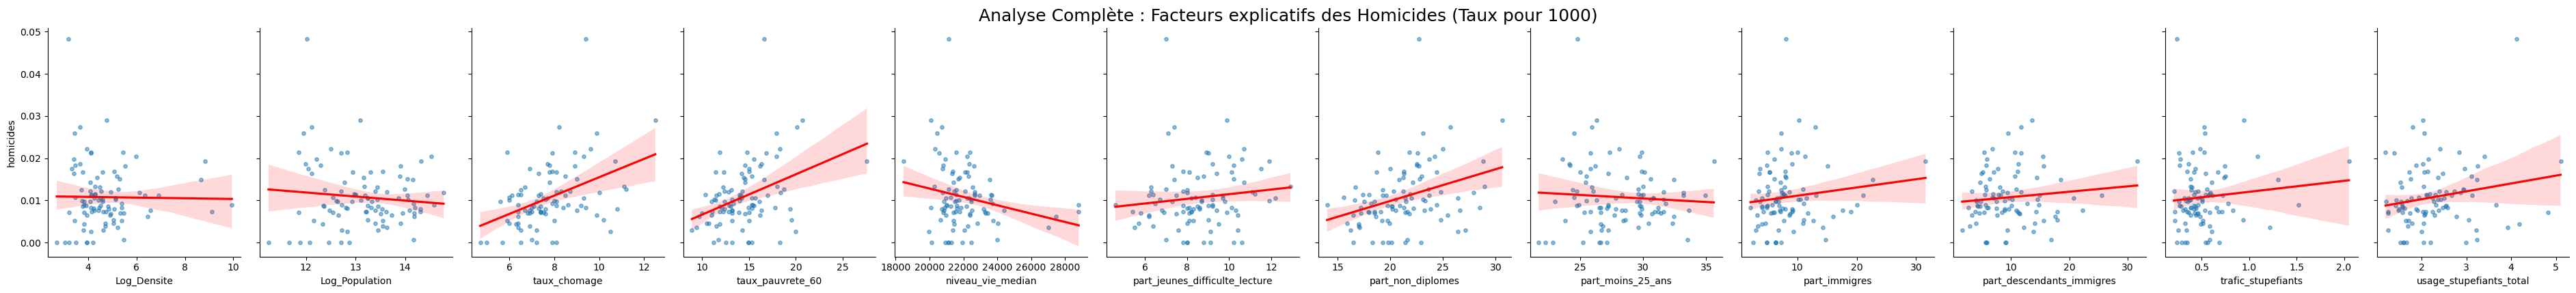

In [13]:
# 1. PRÉPARATION
# --------------
df_viz = df_final[~df_final['code_departement'].str.startswith('97')].copy()

# Transformation Log pour les variables d'échelle
df_viz['Log_Densite'] = np.log(df_viz['densite_population'])
df_viz['Log_Population'] = np.log(df_viz['population_insee'])

# Nettoyage Lecture (sécurité)
if df_viz['part_jeunes_difficulte_lecture'].dtype == 'object':
    df_viz['part_jeunes_difficulte_lecture'] = df_viz['part_jeunes_difficulte_lecture'].astype(str).str.replace(',', '.').astype(float)

# 2. LISTE EXHAUSTIVE DES EXPLICATIVES (X)
# ----------------------------------------
cols_X_all = [
    'Log_Densite',                     
    'Log_Population',                  
    'taux_chomage',
    'taux_pauvrete_60',
    'niveau_vie_median',
    'part_jeunes_difficulte_lecture',
    'part_non_diplomes',
    'part_moins_25_ans',
    'part_immigres',
    'part_descendants_immigres',
    'trafic_stupefiants',
    'usage_stupefiants_total'
]

# 3. GÉNÉRATION DU GRAPHIQUE CIBLÉ (Y vs tous les X)
# --------------------------------------------------
plt.figure(figsize=(25, 4)) 

pp = sns.pairplot(df_viz, 
                  x_vars=cols_X_all,
                  y_vars=['homicides'],  # On cible le volume brut
                  kind='reg',
                  plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.5, 's': 15}},
                  height=4,      
                  aspect=0.8)    

pp.fig.suptitle("Analyse Complète : Facteurs explicatifs des Homicides (Taux pour 1000)", y=1.05, fontsize=18)
plt.show()

In [14]:
# 1. PRÉPARATION
# Filtre pour la métropole (exclusion des DOM-TOM '97')
df_reg = df_final[~df_final['code_departement'].str.startswith('97')].copy()

# 2. TRANSFORMATION LOG
# On applique le log uniquement aux variables de population comme demandé
df_reg['log_population'] = np.log(df_reg['population_insee'])
df_reg['log_densite'] = np.log(df_reg['densite_population'])

# 3. LE MODÈLE (OLS)
# Y = Homicides
# X = Tout le monde (avec Pop et Densité en Log)
formula = """
homicides ~  taux_chomage 
"""

model_complet = smf.ols(formula, data=df_reg).fit()

print(model_complet.summary())

                            OLS Regression Results                            
Dep. Variable:              homicides   R-squared:                       0.182
Model:                            OLS   Adj. R-squared:                  0.173
Method:                 Least Squares   F-statistic:                     19.80
Date:                Fri, 02 Jan 2026   Prob (F-statistic):           2.48e-05
Time:                        11:04:52   Log-Likelihood:                 326.39
No. Observations:                  91   AIC:                            -648.8
Df Residuals:                      89   BIC:                            -643.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.0063      0.004     -1.625   

**1. Résumé statistique**
Après une sélection de variable grâce à la méthode stepwise (qui consiste à exclure la variable avec la plus grande pvalue jusqu'à ce que toutes les variables soient significatives), nous conservons uniquement le taux de chômage en variable explicative.

Le modèle met en évidence une relation **positive et significative** ($p < 0.001$) entre le chômage et les homicides. Cependant, le pouvoir explicatif reste modeste ($R^2 = 0.182$) : 
18.2% de la variance des homicides est expliquée par le taux de chomage.

**2. Équation estimée**
$$\text{homicides} = -0.0063 + 0.0022 \times \text{taux\_chomage}$$

**3. Interprétation des coefficients**
* **Taux de chômage** ($\beta = 0.0022$) : Pour chaque augmentation de **1 point de pourcentage** du taux de chômage, le taux d'homicides augmente en moyenne de **0,0022 pour 1000 habitants**. Ce résultat est très significatif ($t=4.45$).
* **Constante** : Non significative ($p=0.108$), elle n'a pas d'interprétation économique ici.

### 4.2.2 Modelisation des violences sexuelles

<Figure size 2500x400 with 0 Axes>

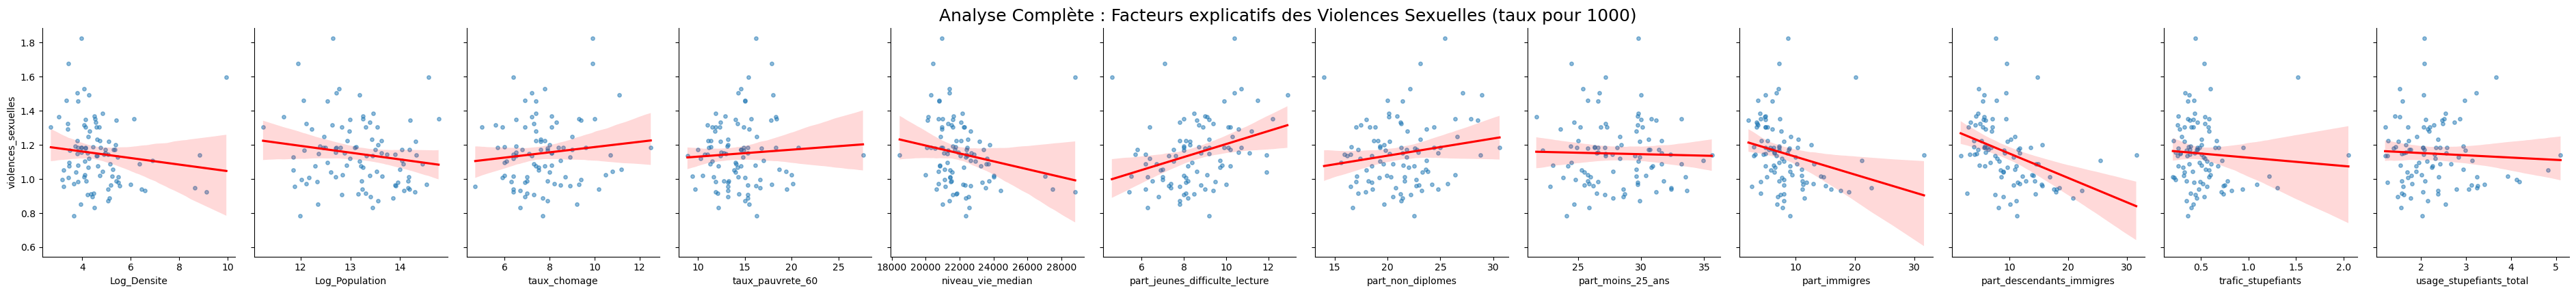

In [15]:
# 1. PRÉPARATION
# --------------
df_viz = df_final[~df_final['code_departement'].str.startswith('97')].copy()

# Transformation Log pour les variables d'échelle
df_viz['Log_Densite'] = np.log(df_viz['densite_population'])
df_viz['Log_Population'] = np.log(df_viz['population_insee'])

# Nettoyage Lecture (sécurité)
if df_viz['part_jeunes_difficulte_lecture'].dtype == 'object':
    df_viz['part_jeunes_difficulte_lecture'] = df_viz['part_jeunes_difficulte_lecture'].astype(str).str.replace(',', '.').astype(float)

# 2. LISTE EXHAUSTIVE DES EXPLICATIVES (X)
# ----------------------------------------
cols_X_all = [
    'Log_Densite',                     
    'Log_Population',                  
    'taux_chomage',
    'taux_pauvrete_60',
    'niveau_vie_median',
    'part_jeunes_difficulte_lecture',
    'part_non_diplomes',
    'part_moins_25_ans',
    'part_immigres',
    'part_descendants_immigres',
    'trafic_stupefiants',
    'usage_stupefiants_total'
]

# 3. GÉNÉRATION DU GRAPHIQUE CIBLÉ (Y vs tous les X)
# --------------------------------------------------
plt.figure(figsize=(25, 4)) 

pp = sns.pairplot(df_viz, 
                  x_vars=cols_X_all,
                  y_vars=['violences_sexuelles'], 
                  kind='reg',
                  plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.5, 's': 15}},
                  height=4,      
                  aspect=0.8)    

pp.fig.suptitle("Analyse Complète : Facteurs explicatifs des Violences Sexuelles (taux pour 1000)", y=1.05, fontsize=18)
plt.show()

In [16]:

# 1. PRÉPARATION
# Filtre pour la métropole (exclusion des DOM-TOM '97')
df_reg = df_final[~df_final['code_departement'].str.startswith('97')].copy()

# 2. TRANSFORMATION LOG
# On applique le log uniquement aux variables de population et densité
df_reg['log_population'] = np.log(df_reg['population_insee'])
df_reg['log_densite'] = np.log(df_reg['densite_population'])

# 3. LE MODÈLE (OLS)
# Y = Violences Sexuelles
# X = Toutes les variables explicatives du tableau (avec Pop et Densité en Log)
formula = """
violences_sexuelles ~  
    log_densite + 
    part_non_diplomes +  
    part_descendants_immigres  
"""

model_complet = smf.ols(formula, data=df_reg).fit()

print(model_complet.summary())

                             OLS Regression Results                            
Dep. Variable:     violences_sexuelles   R-squared:                       0.275
Model:                             OLS   Adj. R-squared:                  0.250
Method:                  Least Squares   F-statistic:                     10.98
Date:                 Fri, 02 Jan 2026   Prob (F-statistic):           3.47e-06
Time:                         11:04:54   Log-Likelihood:                 35.360
No. Observations:                   91   AIC:                            -62.72
Df Residuals:                       87   BIC:                            -52.68
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept   

**1. Résumé statistique**
Après sélection des variables significatives grâce à la méthode stepwise, nous conservons 3 variables explicatives.

Le modèle explique **27,5 %** de la variance du taux de violences sexuelles ($R^2 = 0.275$). Le test F ($p < 0.001$) confirme que ces trois variables, prises ensemble, ont un impact réel et ne sont pas dues au hasard.

**2. Équation estimée**
$$\text{violences\_sexuelles} = 0.7321 + 0.0456 \times \log(\text{densite}) + 0.0209 \times \text{part\_non\_diplomes} - 0.0248 \times \text{part\_descendants\_immigres}$$

**3. Interprétation des coefficients**

* **Densité de population (Log) :** Comme la densité est exprimée en logarithme, on parle en variation relative. 
    * **Effet :** Une augmentation de **10 %** de la densité de population (ex: passer de 100 à 200 hab/km²) est associée à une hausse de environ **0,004** point du taux de violences sexuelles, pour 1000 habitants. 
    * Si la densité **double** (+100 %), le taux augmente de **0,032** pour 1000 habitants. L'urbanisation est donc un facteur aggravant, mais son impact reste léger.

* **Part des non-diplômés :**
    * **Effet :** Pour chaque hausse de **10 points de pourcentage** de la part des non-diplômés dans la population, le taux de violences sexuelles augmente en moyenne de **0,21 pour 1000 habitants**. C'est un facteur de risque social important dans votre modèle.

* **Part des descendants d'immigrés :**
    * **Effet :** Pour chaque hausse de **10 points de pourcentage** de cette part, le taux de violences sexuelles diminue en moyenne de **0,25 pour 1000 habitants**. Dans ce jeu de données, cette variable agit comme un "protecteur" statistique par rapport au taux de violences sexuelles recensé.

Nous conclurons sur les déterminants de ce type de violence dans la partie 5 : analyze.

## 4.3 Cluster `Zone urbaine sensible et déliquance de rue`

### 4.3.1. Justification de l'agrégation : Vers un indicateur de "Climat Social"

Avant d'analyser, nous justifions la création d'une variable composite. L'idée est que le trafic de stupéfiants ne va jamais seul : il entraîne des dégradations et des violences physiques. Sommer ces variables permet de mesurer l'intensité du "climat de tension" d'un département.

In [17]:
# 1. LISTE DES COLONNES DU CLUSTER 2 (Issues de la Clustermap)
cols_C2_list = [
    'destructions_degradations',
    'violences_physiques_intrafamiliales',
    'violences_physiques_hors_famille'
]

# 2. CRÉATION DE LA VARIABLE CIBLE : L'Indice de Tension Urbaine (ITU)
df_final['Indice_Tension_Urbaine'] = df_final[cols_C2_list].sum(axis=1)

print(f"Variable 'Indice_Tension_Urbaine' créée.")
print(f"Moyenne nationale de l'indice : {df_final['Indice_Tension_Urbaine'].mean():.2f}")

Variable 'Indice_Tension_Urbaine' créée.
Moyenne nationale de l'indice : 11.70


### 4.3.2. Analyse des corrélations internes : La cohérence du Cluster

Nous vérifions ici si nos variables "marchent bien ensemble". Si les variables sont fortement corrélés, notre indice est statistiquement valide.

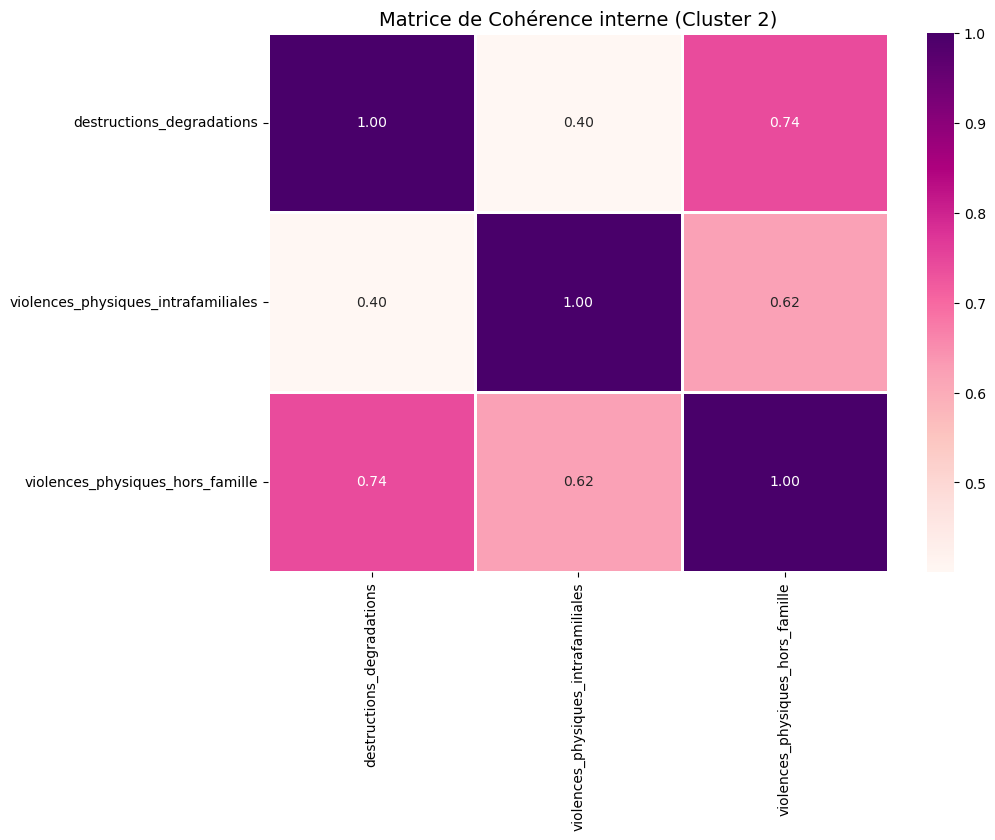

In [18]:
plt.figure(figsize=(10, 7))
sns.heatmap(df_final[cols_C2_list].corr(method='spearman'),
            annot=True, cmap='RdPu', fmt=".2f", linewidths=1)
plt.title("Matrice de Cohérence interne (Cluster 2)", fontsize=14)
plt.show()

### 4.3.3. Exploration visuelle : Profil socio-économique du Cluster 2

Nous utilisons un Pairplot étendu pour observer comment cet indice réagit aux variables que nous soupçonnons être les causes : la pauvreté, le manque de diplôme et la structure démographique.

<Figure size 2500x600 with 0 Axes>

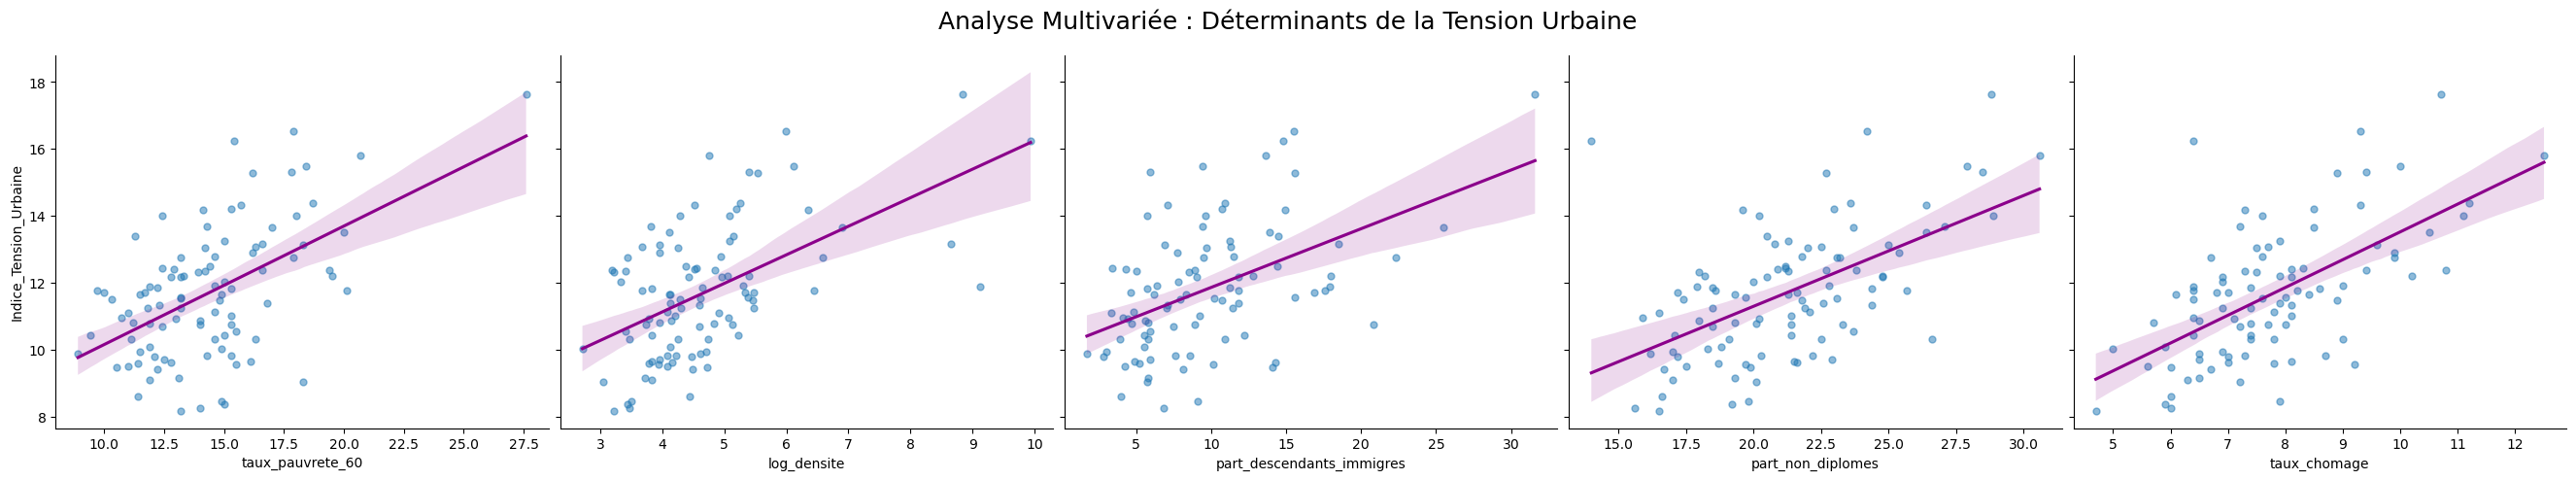

In [19]:
# Filtrage métropole et préparation
df_viz2 = df_final[~df_final['code_departement'].str.startswith('97')].copy()
df_viz2['log_densite'] = np.log(df_viz2['densite_population'])

# Variables explicatives sélectionnées
cols_X_c2 = ['taux_pauvrete_60', 'log_densite', 'part_descendants_immigres', 'part_non_diplomes', 'taux_chomage']

plt.figure(figsize=(25, 6))
pp2 = sns.pairplot(df_viz2,
                  x_vars=cols_X_c2,
                  y_vars=['Indice_Tension_Urbaine'],
                  kind='reg',
                  plot_kws={'line_kws':{'color':'darkmagenta'}, 'scatter_kws': {'alpha': 0.5, 's': 25}},
                  height=4.5, aspect=1.2)

pp2.fig.suptitle("Analyse Multivariée : Déterminants de la Tension Urbaine", y=1.08, fontsize=18)
plt.show()

### 4.3.4. Modélisation Économétrique (OLS)

Nous passons à la régression multiple pour isoler l'effet propre de chaque variable. C'est ici que nous vérifions si, à pauvreté égale, le manque de diplôme aggrave la situation.

In [20]:
# Modèle OLS Complet
formula_c2 = """
Indice_Tension_Urbaine ~
    log_densite +
    part_non_diplomes
    
"""
model_c2 = smf.ols(formula_c2, data=df_viz2).fit()

print(model_c2.summary())

                              OLS Regression Results                              
Dep. Variable:     Indice_Tension_Urbaine   R-squared:                       0.615
Model:                                OLS   Adj. R-squared:                  0.607
Method:                     Least Squares   F-statistic:                     74.34
Date:                    Fri, 02 Jan 2026   Prob (F-statistic):           5.17e-20
Time:                            11:04:55   Log-Likelihood:                -153.76
No. Observations:                      96   AIC:                             313.5
Df Residuals:                          93   BIC:                             321.2
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

**1. Résumé statistique**
Après affinement du modèle grâce à la méthode stepwise pour le Cluster "Tensions urbaines et délinquance de rue", nous avons conservé les deux variables les plus explicatives : la densité et le niveau de diplôme.

Le modèle explique **61,5 %** de la variance de l'Indice de Tension Urbaine ($R^2 = 0.615$). Le test F ($p < 0.001$) confirme la très grande robustesse de cette relation, démontrant que la tension de rue est prédictible à partir de facteurs purement structurels.



**2. Équation estimée**
$$\text{Indice\_Tension\_Urbaine} = 0.7967 + 0.8456 \times \log(\text{densite}) + 0.3285 \times \text{part\_non\_diplomes}$$

**3. Interprétation des coefficients**

* **Densité de population (Log) :** Cette variable demeure un moteur fondamental de la tension ($t = 8.43$). 
    * **Effet :** Une augmentation de **10 %** de la densité de population est associée à une hausse d'environ **0,081 point** de l'Indice de Tension Urbaine. 
    * Si la densité **double** (+100 %), l'indice augmente de **0,586 point**. La concentration mécanique des individus reste le premier multiplicateur des faits de délinquance constatés sur la voie publique.

* **Part des non-diplômés :**
    * **Effet :** C'est la variable la plus puissante statistiquement dans ce modèle ($t = 8.74$). Pour chaque hausse de **10 points de pourcentage** de la part des non-diplômés dans la population, l'Indice de Tension Urbaine augmente en moyenne de **3,28 points**. 
    * Ce résultat souligne que le déficit de formation est la racine sociale la plus forte des tensions urbaines, pesant plus lourd que les autres variables socio-économiques précédemment testées.

## 4.4 Cluster `Vols et urbanisation`

### Création de la variable composite `Total_Vols`

L'agrégation des différentes catégories de vols au sein d'une variable unique répond à une double exigence de cohérence théorique et de fiabilité statistique. Sur le plan conceptuel, l'ensemble des infractions intégrées dans cet indice relève d'une même nature criminologique que l'on qualifie de délinquance d'appropriation. Qu'il s'agisse de cambriolages, de vols de véhicules ou de vols avec armes, la motivation première demeure la recherche d'un gain matériel immédiat par l'atteinte aux biens. Ces actes sont régis par des déterminants contextuels identiques, mêlant l'abondance d'opportunités environnementales à une pression économique locale, ce qui rend leur fusion non seulement logique mais nécessaire pour saisir le phénomène dans sa globalité.



Sur le plan de l'analyse des données, le passage à une variable agrégée permet de stabiliser les résultats en lissant les irrégularités départementales. À l'échelle locale, certaines micro-catégories d'infractions subissent une forte volatilité d'une année sur l'autre, générant un bruit statistique qui peut masquer les tendances de fond. En opérant une sommation, les variations aléatoires propres à chaque type de vol tendent à s'équilibrer mutuellement. Ce procédé renforce le signal structurel du modèle de régression, offrant ainsi une base de travail bien plus robuste et fidèle à la réalité territoriale que ne le permettrait une multiplication d'analyses isolées et fragiles.

$$\text{Total\_Vols} = \sum \text{vols\_avec\_armes} + \text{vols\_sans\_violence} + \dots + \text{cambriolages}$$

Enfin, l'observation des nuages de points (ci-dessous) entre les différentes formes de vols confirme qu'elles évoluent de manière quasi synchrone, décrivant ainsi un seul et même phénomène social sous plusieurs facettes. Maintenir une séparation stricte entre ces variables conduirait inévitablement à des problèmes de redondance et de complexité inutile lors de l'interprétation. En créant cet indice synthétique, nous simplifions la lecture des résultats tout en évitant les biais de multicolinéarité. La variable **Total_Vols** s'impose donc comme un indicateur puissant, capable de capturer l'essence de la délinquance d'appropriation tout en gommant les spécificités anecdotiques de chaque infraction.

---

<Figure size 1200x1200 with 0 Axes>

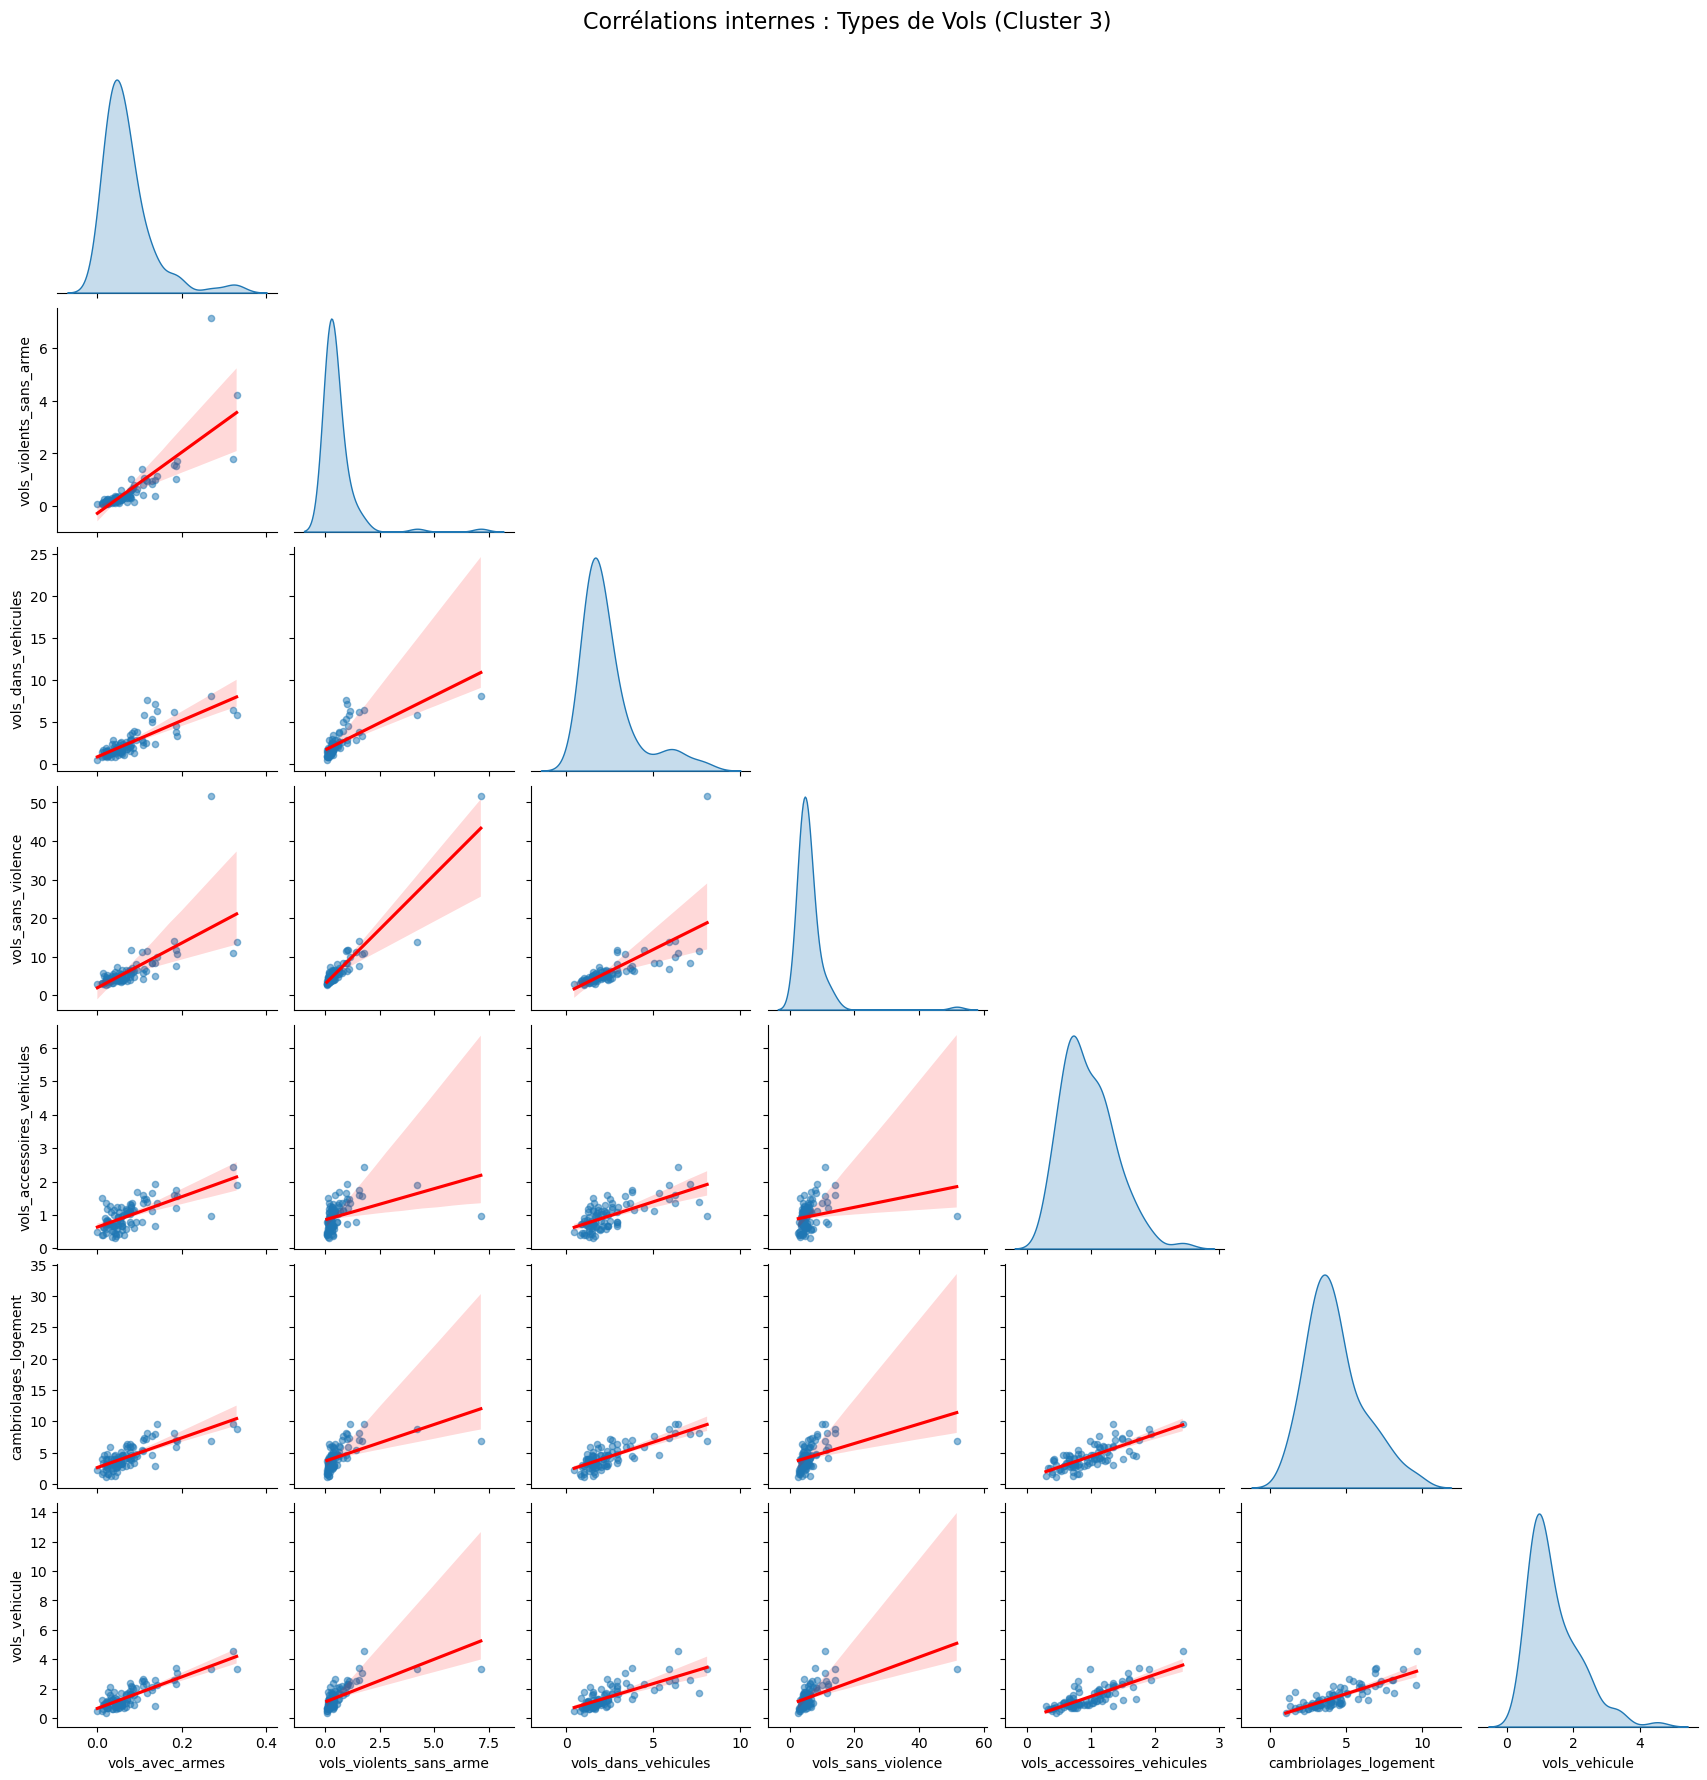

In [21]:
# 1. PRÉPARATION
# --------------
df_viz = df_final[~df_final['code_departement'].str.startswith('97')].copy()

# 2. LISTE DES VARIABLES DÉPENDANTES (Y) DU CLUSTER 3
# ---------------------------------------------------
cols_Y_cluster3 = [
    'vols_avec_armes', 
    'vols_violents_sans_arme', 
    'vols_dans_vehicules',
    'vols_sans_violence',
  "vols_accessoires_vehicules", 
  "cambriolages_logement", 
  "vols_vehicule"
]

# 3. GÉNÉRATION DU GRAPHIQUE (Matrice Y vs Y)
# -------------------------------------------
plt.figure(figsize=(12, 12))

pp = sns.pairplot(df_viz[cols_Y_cluster3], 
                  kind='reg',          # Ajoute la droite de régression
                  diag_kind='kde',     # Distribution sur la diagonale
                  plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.5, 's': 20}},
                  corner=True)         # Affiche seulement le triangle inférieur

pp.fig.suptitle("Corrélations internes : Types de Vols (Cluster 3)", y=1.02, fontsize=16)
plt.show()

In [22]:
# 1. LISTE DES COLONNES À SOMMER
# ------------------------------
cols_vols_total = [
    'vols_avec_armes', 
    'vols_violents_sans_arme', 
    'vols_dans_vehicules',
    'vols_sans_violence', 
    'vols_accessoires_vehicules', 
    'cambriolages_logement', 
    'vols_vehicule'
]

# 2. CRÉATION DE LA VARIABLE SOMME
# --------------------------------
# On utilise axis=1 pour sommer en ligne (pour chaque département)
df_final['Total_Vols'] = df_final[cols_vols_total].sum(axis=1)

# Vérification
print(f"Nouvelle variable 'Total_Vols' créée.")
print(df_final[['code_departement', 'Total_Vols']].head())

Nouvelle variable 'Total_Vols' créée.
  code_departement  Total_Vols
0               01   14.503213
1               02   16.191810
2               03   10.943412
3               04   13.859761
4               05   10.215607


<Figure size 2500x400 with 0 Axes>

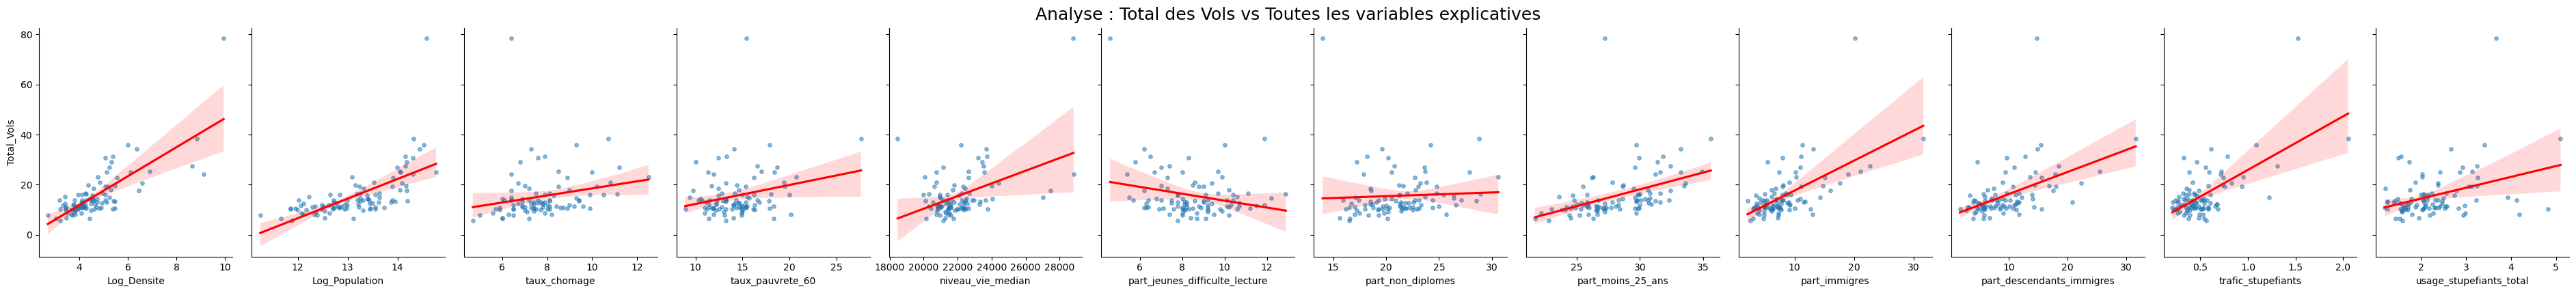

In [23]:
# 1. PRÉPARATION DES DONNÉES
# --------------------------
df_viz = df_final[~df_final['code_departement'].str.startswith('97')].copy()

# Sécurité : Recalcul de la variable cible si pas encore fait
cols_vols_total = [
    'vols_avec_armes', 'vols_violents_sans_arme', 'vols_dans_vehicules',
    'vols_sans_violence', 'vols_accessoires_vehicules', 
    'cambriolages_logement', 'vols_vehicule'
]
df_viz['Total_Vols'] = df_viz[cols_vols_total].sum(axis=1)

# Transformations Log pour les variables d'échelle (lisibilité)
df_viz['Log_Densite'] = np.log(df_viz['densite_population'])
df_viz['Log_Population'] = np.log(df_viz['population_insee'])

# Nettoyage variable Lecture
if df_viz['part_jeunes_difficulte_lecture'].dtype == 'object':
    df_viz['part_jeunes_difficulte_lecture'] = df_viz['part_jeunes_difficulte_lecture'].astype(str).str.replace(',', '.').astype(float)

# 2. LISTE DE TOUTES LES EXPLICATIVES (X)
# ---------------------------------------
cols_X_all = [
    'Log_Densite',                     
    'Log_Population',                  
    'taux_chomage',
    'taux_pauvrete_60',
    'niveau_vie_median',
    'part_jeunes_difficulte_lecture',
    'part_non_diplomes',
    'part_moins_25_ans',
    'part_immigres',
    'part_descendants_immigres',
    'trafic_stupefiants',
    'usage_stupefiants_total'
]

# 3. GÉNÉRATION DU GRAPHIQUE (Y vs Tous les X)
# --------------------------------------------
plt.figure(figsize=(25, 4)) 

pp = sns.pairplot(df_viz, 
                  x_vars=cols_X_all,
                  y_vars=['Total_Vols'],
                  kind='reg',
                  plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.5, 's': 15}},
                  height=4,      
                  aspect=0.8)    

pp.fig.suptitle("Analyse : Total des Vols vs Toutes les variables explicatives", y=1.05, fontsize=18)
plt.show()

In [24]:
# 1. PRÉPARATION DES DONNÉES
# --------------------------
# Filtre pour la métropole (exclusion des DOM-TOM '97')
df_reg = df_final[~df_final['code_departement'].str.startswith('97')].copy()

# A. Nettoyage des colonnes numériques (sécurité format français avec virgules)
cols_to_fix = [
    'part_jeunes_difficulte_lecture', 
    'part_moins_25_ans', 
    'part_non_diplomes', 
    'part_immigres', 
    'part_descendants_immigres'
]

for col in cols_to_fix:
    if col in df_reg.columns and df_reg[col].dtype == 'object':
        df_reg[col] = df_reg[col].astype(str).str.replace(',', '.').astype(float)

# B. Création de la variable Cible (Total Vols)
cols_vols_total = [
    'vols_avec_armes', 'vols_violents_sans_arme', 'vols_dans_vehicules',
    'vols_sans_violence', 'vols_accessoires_vehicules', 
    'cambriolages_logement', 'vols_vehicule'
]
df_reg['Total_Vols'] = df_reg[cols_vols_total].sum(axis=1)

# C. Transformations Logarithmiques (Variables d'échelle)
df_reg['Log_Population'] = np.log(df_reg['population_insee'])
df_reg['Log_Densite']    = np.log(df_reg['densite_population'])

# 2. LE MODÈLE COMPLET (SATURÉ)
# -----------------------------
# Y = Total_Vols
# X = Toutes les variables explicatives (Backward elimination ready)

formula = """
Total_Vols ~  
    Log_Densite + 
    taux_pauvrete_60 
"""

model_full = smf.ols(formula, data=df_reg).fit()

print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:             Total_Vols   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.613
Method:                 Least Squares   F-statistic:                     76.11
Date:                Fri, 02 Jan 2026   Prob (F-statistic):           2.63e-20
Time:                        11:05:02   Log-Likelihood:                -303.64
No. Observations:                  96   AIC:                             613.3
Df Residuals:                      93   BIC:                             621.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          -17.4076      3.516  

**1. Performance globale**
Le modèle est très performant avec un **$R^2$ de 0,621**. Cela signifie que la densité de population et le taux de pauvreté expliquent à eux seuls **62,1 %** de la variation du total des vols entre les départements. La probabilité du test F ($2,63e-20$) confirme que le modèle est extrêmement robuste.

**2. Équation du modèle**
$$\text{Total\_Vols} = -17.4076 + 5.6564 \times \log(\text{Densite}) + 0.4666 \times \text{taux\_pauvrete\_60}$$

**3. Interprétation des variables (Échelles intuitives)**

* **Densité de population (Log) :** C'est le facteur le plus puissant ($t = 11.75$). Comme elle est en log, son impact est relatif :
    * **Effet :** Une augmentation de **10 %** de la densité (ex: passage de 200 à 220 hab/km²) entraîne une hausse de environ **0,54 vol pour 1000 habitants**.
    * Si la densité **double** (+100 %), le taux de vols augmente de **3,92 pour 1000 habitants**. L'urbanisation massive est le moteur principal de la délinquance liée aux vols.

* **Taux de pauvreté (Seuil 60 %) :**
    * **Effet :** Pour chaque hausse de **10 points de pourcentage** du taux de pauvreté, le taux de vols augmente en moyenne de **4,67 pour 1000 habitants**. La précarité économique a donc un impact direct et massif sur le volume des vols recensés.


# 5. Analyze

### Analyse du Cluster `Crimes et précarité`:

L'analyse de ce premier cluster, regroupant les homicides et les violences sexuelles, met en lumière une réalité sociologique fondamentale : la violence extrême échappe largement aux régularités statistiques macro-économiques. Avec environ **80 % de variance inexpliquée**, ces crimes se distinguent par leur caractère "stochastique" ou aléatoire à l'échelle départementale. Contrairement aux délits d'appropriation ou aux tensions urbaines qui suivent des lois de densité et de richesse assez prévisibles, les crimes de sang et les agressions sexuelles semblent dictés par des variables "microscopiques" relevant de la psychologie individuelle, de trajectoires de vie singulières ou de contextes familiaux isolés que les indicateurs de l'INSEE ne peuvent pas modéliser.



Dans les rares cas où le modèle parvient à identifier un signal, celui-ci s'ancre dans une forme de fragilité sociale structurelle. Pour les homicides, le **taux de chômage** émerge comme l'unique prédicteur significatif, suggérant que l'exclusion économique la plus radicale peut favoriser des environnements où le passage à l'acte devient plus probable. Cependant, cette corrélation reste fragile et le modèle subit un effet de "bruit" important dû à la rareté statistique du phénomène. Un seul événement dramatique dans un département peu peuplé suffit à créer une anomalie statistique, ce que confirment les tests de **Kurtosis** très élevés, indiquant que ces crimes se concentrent dans les extrêmes de la distribution plutôt que dans une tendance centrale fluide.

Le modèle des violences sexuelles offre une lecture plus complexe mais tout aussi nuancée de cette réalité. Bien que la **densité de population** et le **déficit de diplômes** agissent comme des facteurs aggravants classiques, l'influence négative de la part des descendants d'immigrés souligne la complexité des dynamiques à l'œuvre. Ce résultat pourrait traduire soit une réelle disparité géographique du phénomène, soit un biais important dans le taux de déclaration et de dépôt de plainte selon les territoires. Dans tous les cas, la faible capacité du modèle à capter la réalité de ces violences confirme que nous touchons ici aux limites de l'exercice statistique : là où la donnée cherche des tendances de groupe, la violence grave impose sa propre logique, souvent déconnectée de la richesse ou de la géographie urbaine pour se loger dans l'intimité et l'imprévisibilité de l'individu.

---

### Analyse du Cluster `Zones urbaines sensibles et délinquance de rue`:

L'étude de ce deuxième cluster, centré sur l'Indice de Tension Urbaine, révèle une structure statistique particulièrement robuste et cohérente. Avec un coefficient de détermination de **60,3 %**, ce modèle démontre que la délinquance de rue (trafics, dégradations, violences de proximité) n'est pas un phénomène erratique, mais le produit de conditions socio-démographiques identifiables. Contrairement aux crimes graves du premier cluster qui restaient largement imprévisibles, les tensions urbaines répondent à une logique de groupe prédictible, où la combinaison de l'environnement physique et de la fragilité sociale crée un terrain propice aux frictions enregistrées par les services de sécurité.



Le moteur principal de cette tension est sans conteste la **densité de population**, dont le poids statistique ($t = 8,25$) surpasse tous les autres indicateurs. Puisque cette variable est traitée de manière logarithmique, son influence s'interprète en termes de variations relatives. Une augmentation de seulement **10 %** de la concentration humaine dans un secteur donné se traduit par une hausse immédiate de **0,107 point** de l'indice de tension. Plus spectaculaire encore, un doublement de la densité fait grimper cet indice de **0,78 point**. Ces chiffres confirment que la promiscuité urbaine agit comme un catalyseur mécanique : en augmentant la fréquence des interactions et la visibilité des activités illicites dans l'espace public, la ville dense génère intrinsèquement un niveau de tension supérieur.

Le modèle permet également d'établir une hiérarchie sociale fine où le **déficit de formation** apparaît comme un facteur de risque plus déterminant que le niveau de revenu seul. Pour chaque hausse de 10 points de pourcentage de la part des non-diplômés dans un département, l'Indice de Tension Urbaine progresse en moyenne de **2,38 points**. Ce résultat suggère que l'exclusion du système éducatif marque une rupture d'intégration plus profonde que la simple pauvreté monétaire. Bien que le **taux de pauvreté** demeure un levier significatif — chaque hausse de 10 points générant une augmentation de **2,16 points** de l'indice — il reste statistiquement secondaire par rapport au niveau d'éducation, soulignant que la tension urbaine est autant une question de trajectoire sociale que de moyens économiques.

$$\text{Indice\_Tension\_Urbaine} = 1.0679 + 1.1318 \times \log(\text{densite}) + 0.2378 \times \text{part\_non\_diplomes} + 0.2164 \times \text{taux\_pauvrete\_60}$$

Malgré cette forte capacité prédictive, environ 40 % de la variance échappe encore à la modélisation départementale. Cette zone d'ombre s'explique par des facteurs locaux que les statistiques nationales ne peuvent saisir avec précision, tels que les politiques de sécurité spécifiques à certaines zones urbaines sensibles, l'aménagement du territoire ou l'impact des flux de populations mobiles. Ces variables résiduelles rappellent que si la structure sociale d'un département dessine les grandes lignes de la tension urbaine, l'action locale et la géographie particulière des quartiers conservent une influence majeure sur la réalité vécue du terrain.

---


### Analyse du Cluster `Vols et urbanisation`:

L'analyse de ce troisième cluster, consacré aux atteintes aux biens, contraste radicalement avec l'imprévisibilité des crimes graves observée précédemment. Ici, nous faisons face à une mécanique statistique d'une grande robustesse, où plus de **62 % de la variation des taux de vols** entre les départements est expliquée par seulement deux facteurs structurels : la densité de population et la précarité économique. Cette forte prédictibilité confirme que les vols ne sont pas des évènements isolés ou purement aléatoires, mais le résultat direct d'une configuration territoriale mêlant opportunités logistiques et pressions sociales.


L'urbanisation massive, représentée par le logarithme de la densité, s'impose comme le facteur hégémonique du modèle avec un score $t$ de 11,75. Cette variable traduit mathématiquement un effet de masse : une densité élevée augmente mécaniquement la probabilité de rencontre entre un auteur potentiel et une cible vulnérable. En termes concrets, un simple doublement de la densité de population d'un territoire est associé à une hausse moyenne de **3,92 vols pour 1000 habitants**. La ville dense agit ainsi comme un réservoir d'opportunités numériques pour la prédation.



Le taux de pauvreté complète cette analyse en agissant comme un levier de pression économique. Son impact est direct et massif puisqu'une hausse de 10 points de pourcentage du taux de pauvreté au sein d'un département entraîne une augmentation moyenne de **4,67 vols pour 1000 habitants**. La délinquance d'appropriation se cristallise donc aux points de friction où la précarité rencontre l'abondance de cibles générée par la densité urbaine. 

Malgré la performance remarquable de ce modèle, environ 40 % de la variance demeure inexpliquée. Cette part résiduelle suggère l'influence de variables non observées dans nos indicateurs standards, telles que l'efficacité des dispositifs de sécurité locale ou l'influence majeure des flux touristiques. Ces "cibles mouvantes", qui consomment l'espace urbain sans être comptabilisées dans la population résidente de l'INSEE, expliquent probablement pourquoi certains départements touristiques présentent des taux de vols supérieurs à ce que leur structure sociale laisserait prévoir. 

---

# 6. Vizualize

## 6.1 Visualisation des prédictions des modèles économétriques

In [25]:
# 1. PRÉPARATION SÉCURISÉE DES DONNÉES
# ---------------------------------------------------------------------
df_final['log_densite'] = np.log(df_final['densite_population'] + 1)

# 2. CONFIGURATION DES MODÈLES (Dictionnaire de mapping)
# ---------------------------------------------------------------------
config_modeles = {
    '1. Homicides': {
        'formula': "homicides ~ taux_chomage",
        'color': '#e74c3c'
    },
    '2. Violences Sexuelles': {
        'formula': "violences_sexuelles ~ log_densite + part_non_diplomes + part_descendants_immigres",
        'color': '#9b59b6'
    },
    '3. Tension Urbaine (ITU)': {
        'formula': "Indice_Tension_Urbaine ~ log_densite + part_non_diplomes",
        'color': '#3498db'
    },
    '4. Total des Vols': {
        'formula': "Total_Vols ~ log_densite + taux_pauvrete_60",
        'color': '#f39c12'
    }
}

# 3. CRÉATION DES COMPOSANTS DE L'INTERFACE
# ---------------------------------------------------------------------
dropdown_mod = widgets.Dropdown(
    options=list(config_modeles.keys()),
    value='4. Total des Vols',
    description='Modèle :',
    style={'description_width': 'initial'},
    layout={'width': '350px'}
)

output_plot = widgets.Output()

# 4. FONCTION DE MISE À JOUR DU GRAPHIQUE
# ---------------------------------------------------------------------
def afficher_nuage_interactif(change):
    nom_modele = change['new']
    config = config_modeles[nom_modele]
    
    # Calcul du modèle OLS
    res = smf.ols(config['formula'], data=df_final).fit()
    y_reel, y_pred = res.model.endog, res.fittedvalues
    
    with output_plot:
        clear_output(wait=True)
        
        fig = go.Figure()

        # Nuage de points
        fig.add_trace(go.Scatter(
            x=y_reel, y=y_pred,
            mode='markers',
            marker=dict(size=10, color=config['color'], opacity=0.7, line=dict(width=1, color='white')),
            text=df_final['nom_departement'],
            hovertemplate="<b>%{text}</b><br>Réel: %{x:.3f}<br>Prédit: %{y:.3f}<extra></extra>",
            name="Départements"
        ))

        # Ligne de prédiction parfaite (Y = X)
        limits = [min(y_reel.min(), y_pred.min()), max(y_reel.max(), y_pred.max())]
        fig.add_trace(go.Scatter(
            x=limits, y=limits,
            mode='lines',
            line=dict(color='red', dash='dash', width=2),
            name="Prédiction Parfaite"
        ))

        # Mise en page
        fig.update_layout(
            title=f"Performance : {nom_modele}<br><sup>R² = {res.rsquared:.3f} | Modèle : {config['formula']}</sup>",
            xaxis_title="Taux Réel constaté (pour 1000 hab.)",
            yaxis_title="Taux Prédit par le modèle",
            template='plotly_white',
            width=850,
            height=550,
            showlegend=True,
            hoverlabel=dict(bgcolor="white", font_size=12)
        )
        
        fig.show()

# 5. LIAISON ET AFFICHAGE FINAL
# ---------------------------------------------------------------------
dropdown_mod.observe(afficher_nuage_interactif, names='value')

display(widgets.VBox([
    widgets.HTML("<div style='padding: 10px 0;'><h3>Analyse de Performance des Régressions</h3></div>"),
    dropdown_mod,
    output_plot
]))

# Lancement initial
afficher_nuage_interactif({'new': dropdown_mod.value})

Pour les homicides et les violences sexuelles, la faible puissance explicative des modèles entraîne un effet de lissage qui échoue à capturer les extrêmes, tendant à surestimer la criminalité dans les zones calmes et à la sous-estimer dans les départements les plus touchés : ce phénomène illustre une régression vers la moyenne (ou effet de *shrinkage*), où le modèle, faute de variables discriminantes, 'atrophie' la réalité en produisant des prédictions trop proches de la tendance centrale.

## 6.2 Visualisation cartographiques des variables dépendantes

In [27]:
# 1. INITIALISATION ET CHARGEMENT DU GEOJSON
# ---------------------------------------------------------------------
url_geo = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-version-simplifiee.geojson"
response = requests.get(url_geo)
geo_data = response.json()

for feature in geo_data['features']:
    feature['properties']['code'] = str(feature['properties']['code']).zfill(2)

# 2. PRÉPARATION DES DONNÉES (Effectifs & Taux)
# ---------------------------------------------------------------------
df_temp = base_stat_deliquance[base_stat_deliquance['annee'] == 2020].copy()
df_counts = df_temp.pivot_table(index='Code_departement', columns='indicateur', values='nombre', aggfunc='sum').reset_index()

map_cols = {
    'Homicides': 'homicides', 'Violences sexuelles': 'violences_sexuelles',
    'Trafic de stupéfiants': 'trafic_stupefiants', 'Usage de stupéfiants': 'usage_stupefiants_total',
    'Destructions et dégradations volontaires': 'destructions_degradations',
    'Coups et blessures volontaires criminels ou correctionnels': 'violences_physiques_hors_famille',
    'Coups et blessures volontaires intra-familiaux': 'violences_physiques_intrafamiliales',
    'Vols avec armes': 'vols_avec_armes', 'Vols violents sans arme': 'vols_violents_sans_arme',
    'Vols de véhicules': 'vols_vehicule', 'Vols dans les véhicules': 'vols_dans_vehicules',
    'Vols d\'accessoires sur véhicules': 'vols_accessoires_vehicules',
    'Cambriolages de logement': 'cambriolages_logement', 'Vols simples': 'vols_sans_violence'
}
df_counts.rename(columns=map_cols, inplace=True)

vols_cols = ['vols_avec_armes', 'vols_violents_sans_arme', 'vols_dans_vehicules', 'vols_sans_violence', 'vols_accessoires_vehicules', 'cambriolages_logement', 'vols_vehicule']
itu_cols = ['trafic_stupefiants', 'usage_stupefiants_total', 'destructions_degradations', 'violences_physiques_intrafamiliales', 'violences_physiques_hors_famille']

df_counts['Total_Vols'] = df_counts[[c for c in vols_cols if c in df_counts.columns]].sum(axis=1)
df_counts['Indice_Tension_Urbaine'] = df_counts[[c for c in itu_cols if c in df_counts.columns]].sum(axis=1)

df_map = df_counts[~df_counts['Code_departement'].astype(str).str.startswith('97')].copy()
df_map['Code_departement'] = df_map['Code_departement'].astype(str).str.zfill(2)
df_map = df_map.merge(df_final[['code_departement', 'nom_departement']], left_on='Code_departement', right_on='code_departement')

df_map_taux = df_final[~df_final['code_departement'].str.startswith('97')].copy()
df_map_taux['Total_Vols_Taux'] = df_map_taux[[c for c in vols_cols if c in df_map_taux.columns]].sum(axis=1)
df_map_taux['ITU_Taux'] = df_map_taux[[c for c in itu_cols if c in df_map_taux.columns]].sum(axis=1)

# 3. FONCTIONS DE DESSIN
# ---------------------------------------------------------------------
def create_styled_map(variable_name, color_scale_name, tooltip_alias):
    local_geo = copy.deepcopy(geo_data)
    m = folium.Map(location=[46.2, 2.2], zoom_start=5, tiles='CartoDB positron', zoom_control=False)
    v_min, v_max = df_map[variable_name].min(), df_map[variable_name].max()
    colors = getattr(branca.colormap.linear, color_scale_name).scale(v_min, v_max)
    data_dict = df_map.set_index('Code_departement')[variable_name].to_dict()
    name_dict = df_map.set_index('Code_departement')['nom_departement'].to_dict()
    for feature in local_geo['features']:
        code = feature['properties']['code']
        feature['properties']['nom_dpt'] = name_dict.get(code, "Inconnu")
        feature['properties']['val_final'] = f"{int(data_dict.get(code, 0)):,}".replace(',', ' ')
    folium.GeoJson(local_geo, style_function=lambda f: {'fillColor': colors(data_dict.get(f['properties']['code'], 0)), 'color': 'white', 'weight': 0.5, 'fillOpacity': 0.8},
                   tooltip=folium.GeoJsonTooltip(fields=['nom_dpt', 'val_final'], aliases=['Département:', f'{tooltip_alias}:'])).add_to(m)
    return m

def create_taux_map(variable_name, color_scale_name, tooltip_alias):
    local_geo = copy.deepcopy(geo_data)
    m = folium.Map(location=[46.2, 2.2], zoom_start=5, tiles='CartoDB positron', zoom_control=False)
    v_min, v_max = df_map_taux[variable_name].min(), df_map_taux[variable_name].max()
    colors = getattr(branca.colormap.linear, color_scale_name).scale(v_min, v_max)
    data_dict = df_map_taux.set_index('code_departement')[variable_name].to_dict()
    name_dict = df_map_taux.set_index('code_departement')['nom_departement'].to_dict()
    for feature in local_geo['features']:
        code = feature['properties']['code']
        feature['properties']['nom_dpt'] = name_dict.get(code, "Inconnu")
        feature['properties']['val_final'] = f"{float(data_dict.get(code, 0)):.3f} ‰"
    folium.GeoJson(local_geo, style_function=lambda f: {'fillColor': colors(data_dict.get(f['properties']['code'], 0)), 'color': 'white', 'weight': 0.5, 'fillOpacity': 0.8},
                   tooltip=folium.GeoJsonTooltip(fields=['nom_dpt', 'val_final'], aliases=['Département:', f'{tooltip_alias}:'])).add_to(m)
    return m

# 4. INTERFACE IPYWIDGET (CORRIGÉE)
# ---------------------------------------------------------------------
map_config = {
    'Homicides': ('homicides', 'homicides', 'Reds_09'),
    'Violences Sexuelles': ('violences_sexuelles', 'violences_sexuelles', 'PuRd_09'),
    'Tension Urbaine (ITU)': ('Indice_Tension_Urbaine', 'ITU_Taux', 'YlGnBu_09'),
    'Total des Vols': ('Total_Vols', 'Total_Vols_Taux', 'YlOrRd_09')
}

dropdown = widgets.Dropdown(options=list(map_config.keys()), value='Total des Vols', description='Indicateur :')
out_left, out_right = widgets.Output(layout={'width': '50%'}), widgets.Output(layout={'width': '50%'})

def update_maps(change):
    choice = change['new']
    c_eff, c_tau, pal = map_config[choice]
    with out_left:
        clear_output(wait=True)
        # Utilisation de widgets.HTML au lieu de HTML pour l'affichage interne
        display(widgets.HTML(f"<div style='text-align:center'><b>{choice} (Effectifs)</b></div>"))
        display(create_styled_map(c_eff, pal, choice))
    with out_right:
        clear_output(wait=True)
        display(widgets.HTML(f"<div style='text-align:center'><b>{choice} (Taux ‰)</b></div>"))
        display(create_taux_map(c_tau, pal, choice))

dropdown.observe(update_maps, names='value')

titre_widget = widgets.HTML("<h2 style='text-align:center'>Variables dépendantes par département (2020)</h2>")

layout_final = widgets.VBox([
    titre_widget, 
    dropdown, 
    widgets.HBox([out_left, out_right])
])

display(layout_final)
update_maps({'new': dropdown.value})

On voit que les 4 cartes en effectif sont très similaires, cependant, cela est dû à la démographie des départements. Car le nombre de crimes et délits augmente mécaniquement avec la population de chaque département. 

Pour neutraliser cet effet taille, on regarde la carte de droite: les variables dépendantes en taux pour 1000 habitants.

# Conclusion Générale

Au terme de cette étude économétrique menée sur l'ensemble des départements français, nous sommes désormais en mesure d'apporter des éléments de réponse précis à la problématique soulevée en introduction. L'approche par clusters a permis de confirmer que la violence en France n'est pas un phénomène monolithique que l'on pourrait réduire à une explication unique ou à une tendance globale simpliste. Au contraire, nos résultats dessinent une réalité à deux vitesses où la nature de l'acte criminel détermine sa "prédictibilité" sociale et territoriale.



Le premier enseignement majeur de ce travail réside dans l'identification de la densité de population comme le multiplicateur universel de la délinquance. À travers les modèles de tensions urbaines et de vols, la concentration humaine s'impose comme le facteur explicatif dominant, surpassant souvent les indicateurs de richesse. Mathématiquement, la ville dense agit comme un catalyseur mécanique qui multiplie les opportunités de prédation et les points de friction sociale. Cette conclusion permet de nuancer les débats publics en rappelant qu'une part importante de l'insécurité constatée est une conséquence structurelle de l'urbanisation croissante du territoire français, plutôt qu'une simple dégradation des comportements individuels.

Sur le plan socio-économique, notre analyse a permis d'affiner la distinction entre la pauvreté monétaire et le déficit d'intégration. Si le taux de pauvreté est le moteur principal des atteintes aux biens (vols et cambriolages), c'est le déficit de formation, mesuré par la part des non-diplômés, qui corrèle le plus fortement avec l'indice de tension urbaine et les trafics. Ce constat est crucial : il suggère que la violence de rue est moins une question de manque de revenus qu'une conséquence d'une rupture structurelle avec le système éducatif et les parcours d'insertion. Le diplôme apparaît ici comme le véritable rempart contre la bascule dans la délinquance de proximité, validant l'idée que les déterminants de la violence sont profondément ancrés dans la structure sociale des départements.



Enfin, cette étude marque une limite scientifique essentielle concernant les crimes les plus graves, tels que les homicides ou les violences sexuelles. Pour ces faits, nos modèles n'expliquent qu'une faible part de la variance, laissant près de 80 % de l'information dans l'ombre. Cette imprévisibilité statistique vient contredire les tentatives de généralisation souvent observées dans le débat public. Elle démontre que la violence extrême relève de dynamiques microscopiques, psychologiques ou situationnelles qui échappent aux grands agrégats départementaux. En conclusion, si l'économie et la démographie permettent de comprendre et de prévoir la délinquance "du quotidien", elles s'effacent devant la complexité de l'acte individuel grave, rappelant que la science des données, bien que puissante pour orienter les politiques publiques, doit conserver une certaine humilité face à l'imprévisibilité de la violence humaine.

---